# Task 3: Inverse NN to predict permeability using velocity and coordinates

### 0. Importing libraries

In [113]:
%pip install -q numpy pandas matplotlib scipy openpyxl torch


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import random

In [115]:
# Set the same random seed for reproducible runs.
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

In [116]:
# Prefer CUDA, then Apple Metal (MPS), and otherwise use the CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


### 1. Importing dataset

Text(0.5, 1.0, 'Scatter Plot of Water Dam Data')

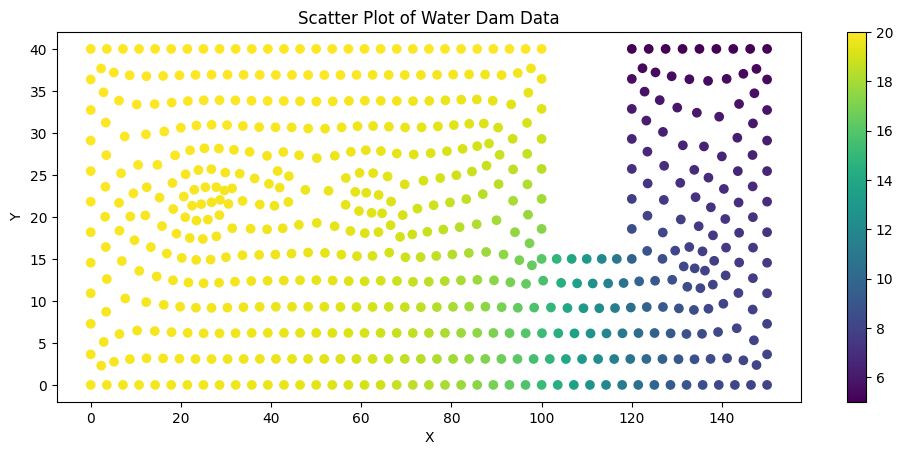

In [139]:
numericldata = pd.read_excel('../Data/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

fig, ax = plt.subplots()

scatter = ax.scatter(X, Y, c=h, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.set_figwidth(12)
ax.set_title('Scatter Plot of Water Dam Data')

### Load observed velocity data
This dataset contains the measured velocity magnitude `VINIT` at known `(X, Y)` points. These values are not used to train the forward head PINN; they are kept for the inverse step where `k` is estimated.

Text(0.5, 1.0, 'Scatter Plot of velocities of Water Dam Data')

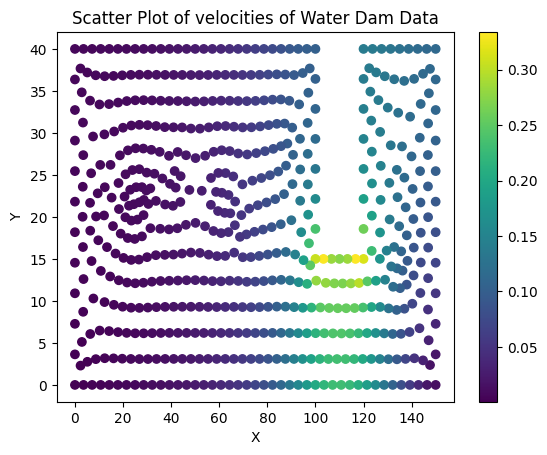

In [118]:
numeric_vel_ldata = pd.read_excel('../Data/velocities/20_5_25.xlsx',header=0)
v = numeric_vel_ldata['VINIT'].to_numpy()
X_v = numeric_vel_ldata['X'].to_numpy()
Y_v = numeric_vel_ldata['Y'].to_numpy()

fig, ax = plt.subplots()

scatter = ax.scatter(X_v, Y_v, c=v, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of velocities of Water Dam Data')

### 2. Normalizing variables

#### Setting up default variables

In [119]:
# Geometry of problem
h1 = 20
h2 = 5
hd = 25

L = 150

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = L   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam


In [120]:
def interpolate_head(X, Y, h, 
                     grid_res=(300, 100),
                     domain_bounds=(x_left, x_right, y_bot, y_top),
                     dam_bounds=(x_dleft, x_dright, y_dbot, y_top),
                     method="linear"):
    
    x_min, x_max, y_min, y_max = domain_bounds
    num_x, num_y = grid_res

    # Generate regular 2D grid
    xi = np.linspace(x_min, x_max, num_x)
    yi = np.linspace(y_min, y_max, num_y)
    grid_x, grid_y = np.meshgrid(xi, yi)

    # Interpolate scattered points
    grid_h = griddata((X,Y), h, (grid_x, grid_y), method=method)

    # Mask out dam region
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    # Replace all h values within the dam area with nan
    grid_h[dam_mask] = np.nan

    return grid_x, grid_y, grid_h

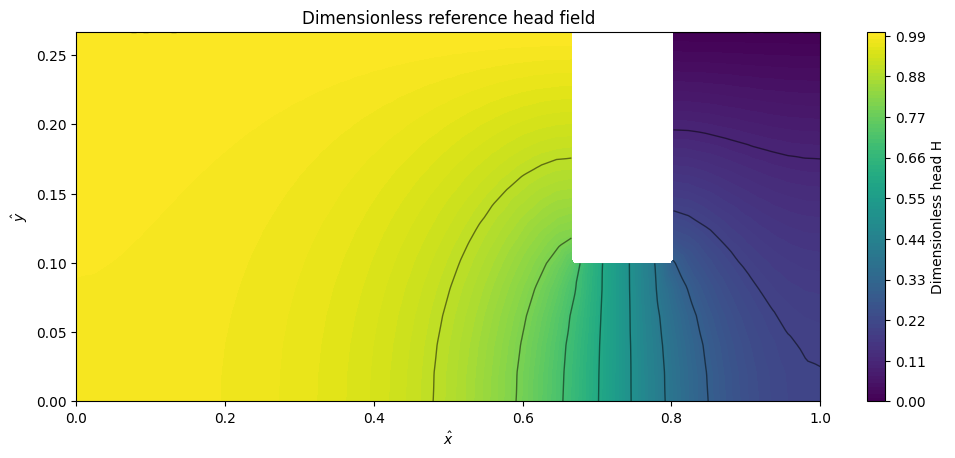

In [138]:
grid_X, grid_Y, grid_h = interpolate_head(X, Y, h)
def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def to_hat_head(h):
    return (h-h2)/(h1-h2)

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

grid_X_hat, grid_Y_hat, grid_h_hat = to_hat_xy(grid_X), to_hat_xy(grid_Y), to_hat_head(grid_h)

fig, ax = plt.subplots()
contour = ax.contourf(grid_X_hat, grid_Y_hat, grid_h_hat, levels=100, cmap="viridis")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Dimensionless head H')
ax.contour(grid_X_hat, grid_Y_hat, grid_h_hat, levels=10, colors='black', linewidths=1, alpha=0.5)
ax.set_xlabel(r'$\hat{x}$')
ax.set_ylabel(r'$\hat{y}$')
fig.set_figwidth(12)
ax.set_title('Dimensionless reference head field')
plt.show()

### 3. Setting up boundary conditions for loss function

In [146]:
# normalise domain and dam bounds
# xmin, xmax, ymin, ymax
domain_bounds = np.array([x_left, x_right, y_bot, y_top])
dam_bounds = np.array([x_dleft, x_dright, y_dbot, y_top])

domain_bounds_norm = to_hat_xy(domain_bounds)
dam_bounds_norm = to_hat_xy(dam_bounds)

print(domain_bounds_norm)
print(dam_bounds_norm)

[0.         1.         0.         0.26666667]
[0.66666667 0.8        0.1        0.26666667]


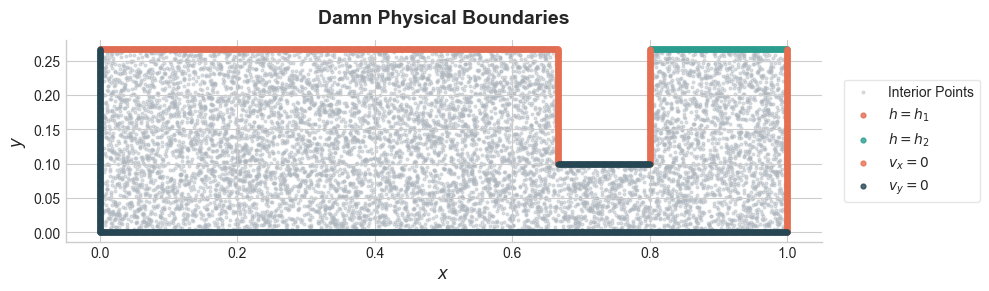

In [154]:
import matplotlib.pyplot as plt

# 1. Set up a modern aesthetic and larger figure dimensions
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 5)) # Wider figure width

# 2. Define a modern, harmonious color palette
h1_color = "#E06D53"   # Terracotta / Muted Orange
h2_color = "#2A9D8F"   # Teal / Modern Green
vx0_color = "#E76F51"  # Coral Red
vy0_color = "#264653"  # Deep Slate Blue
interior_color = "#ADB5BD" # Soft cool grey

# 3. Plot interior points first (background layer)
ax.scatter(
    xy_internal[:, 0], 
    xy_internal[:, 1], 
    color=interior_color, 
    s=4,           
    alpha=0.4,     
    zorder=0,      
    label="Interior Points"
)

# 4. Plot boundary conditions with refined styling
ax.scatter(x_bc_h1, y_bc_h1, color=h1_color, s=12, alpha=0.8, zorder=2, label="$h=h_1$")
ax.scatter(x_bc_h2, y_bc_h2, color=h2_color, s=12, alpha=0.8, zorder=2, label="$h=h_2$")
ax.scatter(x_bc_vx0, y_bc_vx0, color=vx0_color, s=12, alpha=0.8, zorder=2, label="$v_x=0$")
ax.scatter(x_bc_vy0, y_bc_vy0, color=vy0_color, s=12, alpha=0.8, zorder=2, label="$v_y=0$")

# 5. Modernize layout and labels
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("$x$", fontsize=12, fontweight='medium')
ax.set_ylabel("$y$", fontsize=12, fontweight='medium')
ax.set_title("Damn Physical Boundaries", fontsize=14, fontweight='bold', pad=12)

# 6. Place the legend completely outside on the right side
ax.legend(
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0', 
    fontsize=10, 
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5), # Shifts the box outside to the right
    shadow=False
)

# Remove harsh top/right spines for a cleaner modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use bbox_inches='tight' so the side legend isn't cut off when rendering/saving
plt.tight_layout()
plt.show()

Define PINN Loss functions

Our model receives non-dimensional coordinates and predicts non-dimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

We have two types of loss: boundary condition loss and PDE loss. Each boundary type has its own loss:





In [145]:
# when head must have a specfic numerical value at boundary
def loss_bc_value(model, x, y, val):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)

    bc_real = torch.full_like(H, val, device=device)
    bc_loss = torch.mean((H - bc_real)**2)
    return bc_loss

# when one of the derivatives must vanish
# dim = 0 or 1 (x or y)
def loss_bc_grad(model, x, y, dim):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    
    u = x if dim==0 else y
    H_u = torch.autograd.grad(H, u,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    # derivative should vanish, so nonzero value is taken as loss
    bc_loss = torch.mean((H_u)**2)
    return bc_loss

# PDE loss, from LaPlace equation
def loss_pde(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    H_x = torch.autograd.grad(H, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_xx = torch.autograd.grad(H_x, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_y = torch.autograd.grad(H, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_yy = torch.autograd.grad(H_y, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    pde_residual = H_xx + H_yy
    return torch.mean(pde_residual**2)


# when y derivative of head must vanish



### 4. Loss Function

 Fixed-weight PINN loss and training

The network maps nondimensional coordinates to nondimensional head:

$$ (\hat{x},\hat{y}) \mapsto H_\theta(\hat{x},\hat{y}). $$

The grouped loss is

$$ \mathcal{L}=\mathcal{L}_{PDE}+\lambda_D\mathcal{L}_D+\lambda_N\mathcal{L}_N, $$

where

$$ \mathcal{L}_{PDE}=\operatorname{MSE}(H_{,\hat{x}\hat{x}}+H_{,\hat{y}\hat{y}},0), $$

$$ \mathcal{L}_D=\operatorname{MSE}(H,1)_{reservoir}+\operatorname{MSE}(H,0)_{catchment}, $$

$$ \mathcal{L}_N=\operatorname{MSE}(H_{,\hat{x}},0)_{vertical}+\operatorname{MSE}(H_{,\hat{y}},0)_{horizontal}. $$


### Defining ML model

In [125]:
class MLP(nn.Module):
    # arch = [inputs] + [hidden neurons]*number + [outputs]
    def __init__(self, arch, act):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(arch) - 1):
            layers.append(nn.Linear(arch[i], arch[i + 1]))
            if i < len(arch) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        out = self.model(inputs)
        return out

Epoch 0: Loss = 3.1264e+01, PDE Loss = 2.7222e-04, BC h1 Loss = 1.0416e+00, BC h2 Loss 6.7134e-05, BC vx0 Loss 0.0003491309762466699, BC vy0 Loss 0.002422192832455039
Epoch 100: Loss = 7.8619e+00, PDE Loss = 2.1267e-01, BC h1 Loss = 1.0502e-01, BC h2 Loss 6.9834e-02, BC vx0 Loss 0.48023614287376404, BC vy0 Loss 0.00046813127119094133
Epoch 200: Loss = 7.4561e+00, PDE Loss = 2.4309e-01, BC h1 Loss = 1.0626e-01, BC h2 Loss 6.5604e-02, BC vx0 Loss 0.40249720215797424, BC vy0 Loss 0.008918063715100288
Epoch 300: Loss = 6.7749e+00, PDE Loss = 6.6630e-02, BC h1 Loss = 1.3194e-01, BC h2 Loss 4.0426e-02, BC vx0 Loss 0.2810899615287781, BC vy0 Loss 0.026385590434074402
Epoch 400: Loss = 6.2882e+00, PDE Loss = 7.3808e-02, BC h1 Loss = 1.0633e-01, BC h2 Loss 4.3154e-02, BC vx0 Loss 0.3244917690753937, BC vy0 Loss 0.021458452567458153
Epoch 500: Loss = 6.0754e+00, PDE Loss = 6.4908e-02, BC h1 Loss = 9.0386e-02, BC h2 Loss 4.3764e-02, BC vx0 Loss 0.3767581582069397, BC vy0 Loss 0.0204471442848444
E

Text(0.5, 0, 'Epoch')

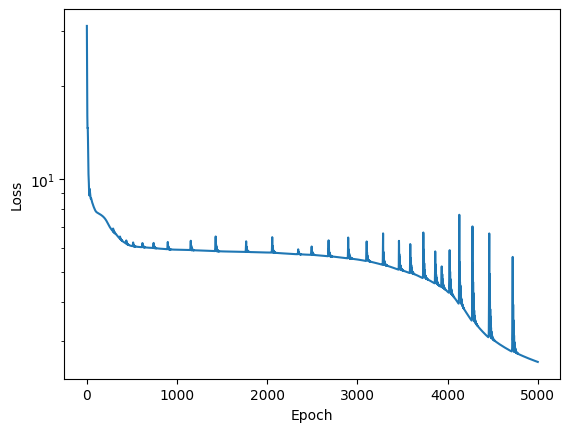

In [126]:
# Create neural network with tanh activation function
layers = [2] + [50]*4 + [1]
model = MLP(layers, nn.Tanh).to(device)
# Save the common initialization for a fair fixed/adaptive comparison.
initial_model_state = {
    name: value.detach().clone() for name, value in model.state_dict().items()
}

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Number of epochs
num_epochs = 5000

lambda_D = 30.0
lambda_N = 5.0

history_fixed = {
    "total": [], "pde": [], "dirichlet": [], "neumann": [],
    "bc_h1": [], "bc_h2": [], "bc_vx0": [], "bc_vy0": [],
}

# Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    # Compute losses
    bc_h1_loss = loss_bc_value(model, bc['h1'][:,0].reshape(-1, 1), bc['h1'][:,1].reshape(-1, 1), 1)
    bc_h2_loss = loss_bc_value(model, bc['h2'][:,0].reshape(-1, 1), bc['h2'][:,1].reshape(-1, 1), 0)
    bc_vx0_loss = loss_bc_grad(model, bc['vx0'][:,0].reshape(-1, 1), bc['vx0'][:,1].reshape(-1, 1), dim=0)
    bc_vy0_loss = loss_bc_grad(model, bc['vy0'][:,0].reshape(-1, 1), bc['vy0'][:,1].reshape(-1, 1), dim=1)
    pde_loss = loss_pde(model, x_internal, y_internal)

    dirichlet_loss = bc_h1_loss + bc_h2_loss
    neumann_loss = bc_vx0_loss + bc_vy0_loss
    loss = pde_loss + lambda_D * dirichlet_loss + lambda_N * neumann_loss
    loss.backward()
    optimizer.step()

    history_fixed["total"].append(loss.item())
    history_fixed["pde"].append(pde_loss.item())
    history_fixed["dirichlet"].append(dirichlet_loss.item())
    history_fixed["neumann"].append(neumann_loss.item())
    history_fixed["bc_h1"].append(bc_h1_loss.item())
    history_fixed["bc_h2"].append(bc_h2_loss.item())
    history_fixed["bc_vx0"].append(bc_vx0_loss.item())
    history_fixed["bc_vy0"].append(bc_vy0_loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4e}, PDE Loss = {pde_loss.item():.4e}, BC h1 Loss = {bc_h1_loss.item():.4e}, BC h2 Loss {bc_h2_loss.item():.4e}, BC vx0 Loss {bc_vx0_loss}, BC vy0 Loss {bc_vy0_loss}")


# Keep a stable reference before creating the adaptive model.
model_fixed = model

epochs = np.arange(1, len(history_fixed["total"]) + 1)
plt.semilogy(epochs, history_fixed["total"])
plt.ylabel("Loss")
plt.xlabel("Epoch")

In [127]:
def predict_head_grid(model, nx=300, ny=100):
    """Evaluate dimensionless H on the aquifer grid and return dimensional h."""
    x_grid = np.linspace(x_left, x_right, nx)
    y_grid = np.linspace(y_bot, y_top, ny)
    x_mesh, y_mesh = np.meshgrid(x_grid, y_grid, indexing="xy")
    xy_dim = np.column_stack([x_mesh.ravel(), y_mesh.ravel()])
    xy_hat = to_hat_xy(xy_dim)

    model.eval()
    with torch.no_grad():
        H_pred = model(torch.as_tensor(xy_hat, dtype=torch.float32, device=device))

    H_pred = H_pred.detach().cpu().numpy().reshape(y_mesh.shape)
    h_pred = from_hat_head(H_pred)
    dam_mask = ((x_mesh >= x_dleft) & (x_mesh <= x_dright) &
                (y_mesh >= y_dbot) & (y_mesh <= y_top))
    return x_mesh, y_mesh, np.ma.masked_where(dam_mask, h_pred)

def plot_head_prediction(model, title, nx=300, ny=100):
    """Plot predicted dimensional head on physical coordinates."""
    x_mesh, y_mesh, h_pred = predict_head_grid(model, nx=nx, ny=ny)

    fig, ax = plt.subplots(figsize=(10, 4))
    levels = np.linspace(h2, h1, 101)
    contour = ax.contourf(
        x_mesh, y_mesh, h_pred, levels=levels, cmap="viridis", extend="both"
    )
    ax.contour(
        x_mesh, y_mesh, h_pred, levels=np.linspace(h2, h1, 11),
        colors="white", linewidths=0.6, alpha=0.55
    )
    ax.fill(
        [x_dleft, x_dright, x_dright, x_dleft],
        [y_dbot, y_dbot, y_top, y_top],
        color="0.6", label="impermeable dam"
    )

    
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label("Predicted hydraulic head h [m]")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bot, y_top)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()
    return fig, ax, h_pred



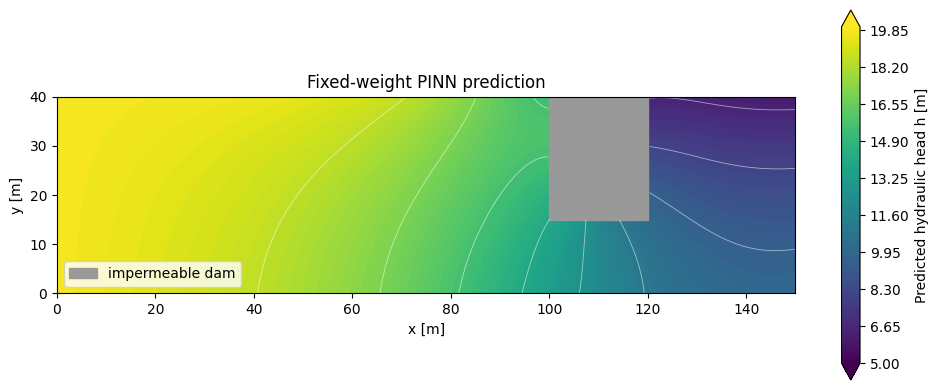

(<Figure size 1000x400 with 2 Axes>,
 <Axes: title={'center': 'Fixed-weight PINN prediction'}, xlabel='x [m]', ylabel='y [m]'>,
 masked_array(
   data=[[19.79314422607422, 19.780780792236328, 19.768390655517578, ...,
          10.00046443939209, 10.006864547729492, 10.013832092285156],
         [19.7928409576416, 19.780521392822266, 19.768165588378906, ...,
          9.982328414916992, 9.988600730895996, 9.995439529418945],
         [19.792564392089844, 19.7802791595459, 19.767969131469727, ...,
          9.963750839233398, 9.969900131225586, 9.976621627807617],
         ...,
         [19.827144622802734, 19.823139190673828, 19.819164276123047, ...,
          6.235290050506592, 6.237453460693359, 6.240046501159668],
         [19.827529907226562, 19.823652267456055, 19.819801330566406, ...,
          6.176962852478027, 6.179059028625488, 6.181583404541016],
         [19.827882766723633, 19.824125289916992, 19.820405960083008, ...,
          6.118276596069336, 6.120299339294434, 6.122754

In [128]:
# Fixed-weight baseline prediction (before adaptive-weight retraining).
plot_head_prediction(model, "Fixed-weight PINN prediction")

### 7. Estimate hydraulic conductivity from predicted head field
The forward PINN has already learned a smooth dimensionless head field `H(x_hat, y_hat)`. For the inverse problem we keep that head model fixed, compute its gradient at the observed velocity locations, and estimate one scalar hydraulic conductivity `k` from Darcy velocity magnitude.

### Prepare the inverse data
Here we select only valid velocity measurements and convert their coordinates to the same dimensionless coordinate system used by the neural network. The velocity values stay dimensional in `m/day`.

In [129]:
# Extract observed velocity magnitudes and their coordinates.
vel_xy = numeric_vel_ldata[["X", "Y"]].to_numpy(dtype=float)
vel_obs = numeric_vel_ldata["VINIT"].to_numpy(dtype=float).reshape(-1, 1)

# Remove missing or invalid rows before using the data in the inverse calculation.
valid_vel = np.isfinite(vel_xy).all(axis=1) & np.isfinite(vel_obs).ravel()
vel_xy_hat = to_hat_xy(vel_xy[valid_vel])
vel_obs = vel_obs[valid_vel]

# Use the trained forward PINN as the source of H. If you later train an
# adaptive model, replace this with: head_model = model_aw
head_model = model

def velocity_factor_from_head(model, xy_hat):
    """Return |grad(h)| without k at the velocity measurement points."""
    xy = torch.tensor(xy_hat, dtype=torch.float32, requires_grad=True, device=device)
    H = model(xy)

    # grad_H is with respect to dimensionless coordinates x_hat, y_hat.
    grad_H = torch.autograd.grad(
        H, xy, grad_outputs=torch.ones_like(H), create_graph=False
    )[0]

    # h = h2 + (h1 - h2) H and x_hat = x / L, so grad(h) = (h1 - h2) / L * grad(H).
    h_gradient_scale = (h1 - h2) / L
    return h_gradient_scale * torch.sqrt(torch.sum(grad_H**2, dim=1, keepdim=True) + 1e-12)

### Estimate `k`
Darcy velocity magnitude can be written as `v = k * factor`, where `factor = |grad(h)|` comes from the trained head model. Because only one scalar `k` is unknown, a direct least-squares estimate is enough and avoids retraining the head network.

In [130]:
# Darcy velocity magnitude is v = k * factor.
head_model.eval()
factor = velocity_factor_from_head(head_model, vel_xy_hat).detach().cpu().numpy()

# Least-squares estimate for one scalar k: minimize mean((k * factor - vel_obs)^2).
k_est = float(np.sum(factor * vel_obs) / np.sum(factor**2))
vel_pred = k_est * factor

# Report how well the estimated k reproduces the observed velocity magnitudes.
velocity_rmse = float(np.sqrt(np.mean((vel_pred - vel_obs)**2)))
velocity_mae = float(np.mean(np.abs(vel_pred - vel_obs)))

print(f"Estimated hydraulic conductivity k = {k_est:.4e} m/day")
print(f"Velocity RMSE = {velocity_rmse:.4e} m/day")
print(f"Velocity MAE  = {velocity_mae:.4e} m/day")

Estimated hydraulic conductivity k = 1.0378e+00 m/day
Velocity RMSE = 4.0668e-02 m/day
Velocity MAE  = 3.2320e-02 m/day


### Visual check of inverse velocity fit
These plots compare the measured velocity magnitudes with the velocities reconstructed from the predicted head gradients and the estimated `k`. A good estimate should put the scatter points close to the dashed `1:1` line and leave residuals centered around zero.

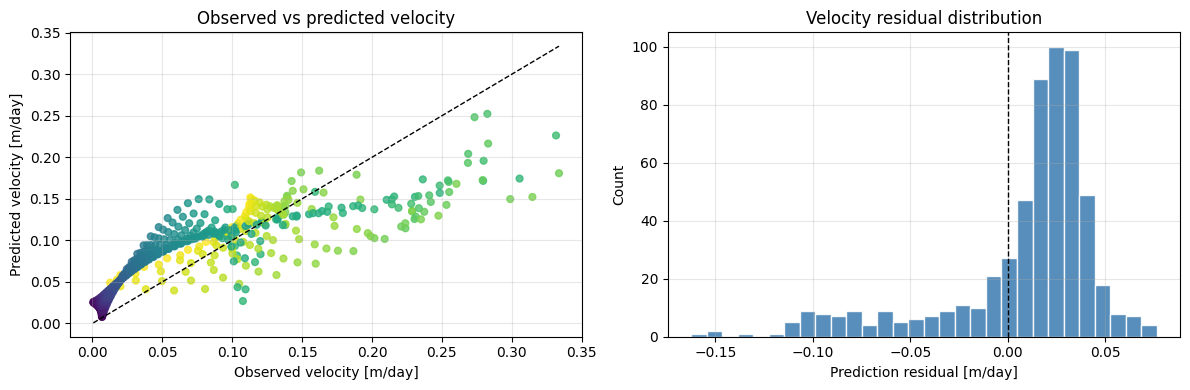

In [131]:
# Compare observed and reconstructed velocity magnitudes.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

obs = vel_obs.ravel()
pred = vel_pred.ravel()
residual = pred - obs
vmin = min(obs.min(), pred.min())
vmax = max(obs.max(), pred.max())

axes[0].scatter(obs, pred, c=vel_xy[valid_vel, 0], cmap="viridis", s=24, alpha=0.8)
axes[0].plot([vmin, vmax], [vmin, vmax], "k--", linewidth=1)
axes[0].set_xlabel("Observed velocity [m/day]")
axes[0].set_ylabel("Predicted velocity [m/day]")
axes[0].set_title("Observed vs predicted velocity")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residual, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Prediction residual [m/day]")
axes[1].set_ylabel("Count")
axes[1].set_title("Velocity residual distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Spatial velocity fit diagnostics
This view shows where the inverse estimate fits well or poorly in the domain. The first panel is measured velocity, the second panel is reconstructed velocity, and the third panel is the signed error.

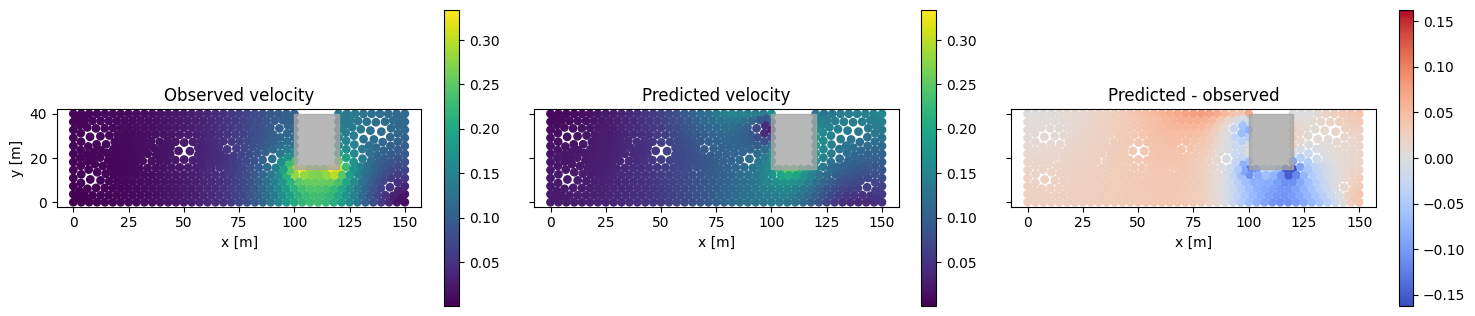

In [132]:
# Spatial maps of observed velocity, predicted velocity, and residuals.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
plot_data = [obs, pred, residual]
titles = ["Observed velocity", "Predicted velocity", "Predicted - observed"]
cmaps = ["viridis", "viridis", "coolwarm"]

abs_res = max(abs(residual.min()), abs(residual.max()))
limits = [(obs.min(), obs.max()), (obs.min(), obs.max()), (-abs_res, abs_res)]

for ax, values, title, cmap, (lo, hi) in zip(axes, plot_data, titles, cmaps, limits):
    sc = ax.scatter(
        vel_xy[valid_vel, 0], vel_xy[valid_vel, 1],
        c=values, cmap=cmap, s=28, vmin=lo, vmax=hi
    )
    ax.fill(
        [x_dleft, x_dright, x_dright, x_dleft],
        [y_dbot, y_dbot, y_top, y_top],
        color="0.65", alpha=0.8
    )
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, shrink=0.8)

axes[0].set_ylabel("y [m]")
plt.tight_layout()
plt.show()

### Compare saved CSV score results
This block loads all CSV files under `Results/`, combines them into one table, and compares the main score columns. It works with both older files that report `rmse_m` and newer files that report `rmse_percent`.

,source_file,model_variant,epochs_completed,rmse_percent,rmse_m,mae_percent,mae_m,max_abs_error_m,relative_l2_error,r2,final_total_loss
5,pinn_fixed_vs_adaptive_2026-07-22_12-37-55-487...,fixed_weights,10000,8.732415,NaN,7.266240,NaN,4.658682,0.076465,0.933019,1.593669
7,pinn_fixed_vs_adaptive_2026-07-22_13-02-43-650...,fixed_weights,10000,8.732415,NaN,7.266240,NaN,4.658682,0.076465,0.933019,1.593669
4,pinn_fixed_vs_adaptive_2026-07-22_12-13-43-903...,adaptive_ntk,5000,17.421570,NaN,14.506670,NaN,6.046605,0.152551,0.733402,3.323462
6,pinn_fixed_vs_adaptive_2026-07-22_12-37-55-487...,adaptive_ntk,10000,17.549871,NaN,14.618287,NaN,6.015162,0.153674,0.729461,3.273609
8,pinn_fixed_vs_adaptive_2026-07-22_13-02-43-650...,adaptive_ntk,10000,17.549871,NaN,14.618287,NaN,6.015162,0.153674,0.729461,3.273609
10,pinn_fixed_vs_adaptive_2026-07-23_10-46-29-346...,adaptive_ntk,1000,19.159857,NaN,15.776225,NaN,8.340653,0.167772,0.677546,4.113000
3,pinn_fixed_vs_adaptive_2026-07-22_12-13-43-903...,fixed_weights,1000,21.625249,NaN,18.009565,NaN,9.037049,0.189360,0.589224,3.986643
9,pinn_fixed_vs_adaptive_2026-07-23_10-46-29-346...,fixed_weights,1000,22.126376,NaN,18.433855,NaN,9.197586,0.193748,0.569966,3.993450
0,adaptive_pinn_results_2026-07-22_11-30-42-7894...,NaN,5000,NaN,4.560007,NaN,4.152723,9.576901,0.266196,0.188234,0.359554
1,pinn_fixed_vs_adaptive_2026-07-22_11-47-52-086...,fixed_weights,1000,NaN,3.243787,NaN,2.701435,9.037049,0.189360,0.589224,3.986643


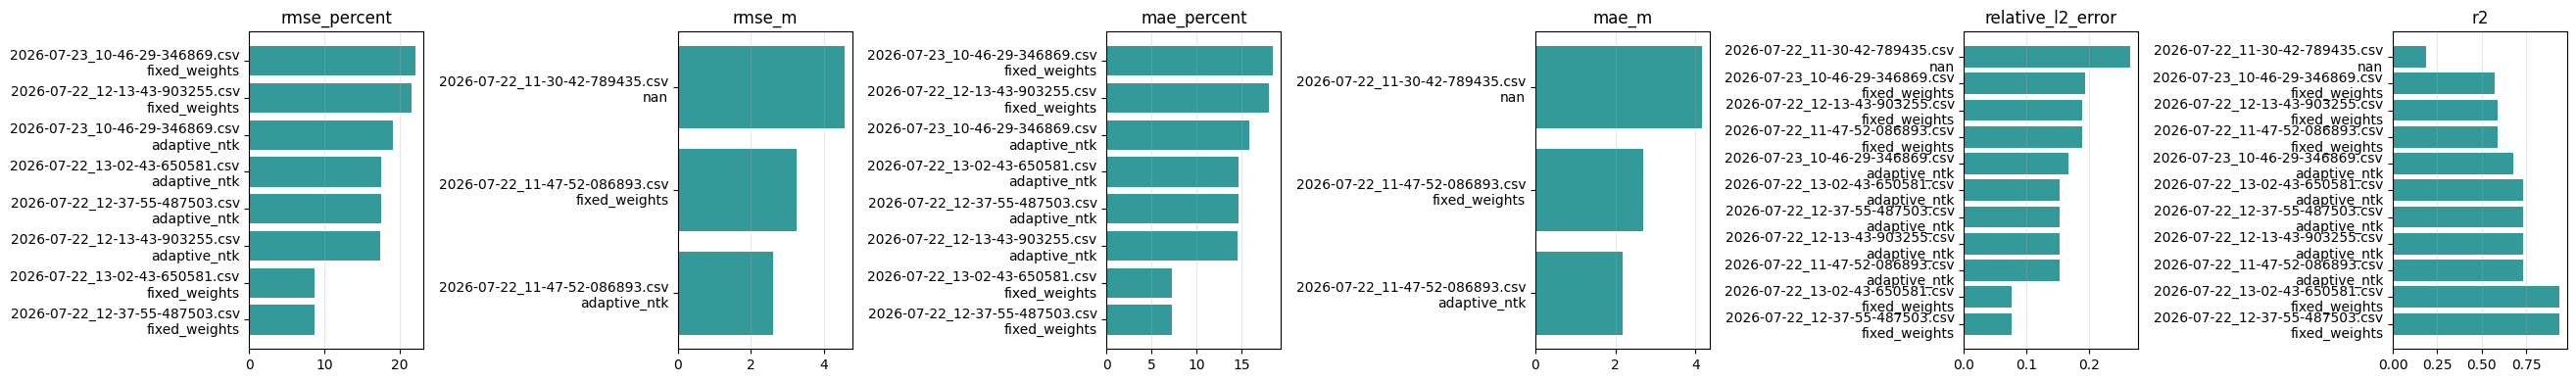

In [133]:
# Compare score CSV files saved under Results/.
from pathlib import Path

result_files = sorted(Path("../Results").rglob("*.csv"))
if not result_files:
    result_files = sorted(Path("Results").rglob("*.csv"))

score_tables = []
for file in result_files:
    df = pd.read_csv(file)
    df["source_file"] = file.name
    df["source_folder"] = file.parent.name
    score_tables.append(df)

if not score_tables:
    print("No CSV files found in Results/.")
else:
    scores = pd.concat(score_tables, ignore_index=True, sort=False)
    if "model_variant" not in scores.columns:
        scores["model_variant"] = scores.get("weighting_method", "run")

    score_cols = [
        col for col in [
            "source_file", "model_variant", "epochs_completed", "rmse_percent", "rmse_m",
            "mae_percent", "mae_m", "max_abs_error_m", "relative_l2_error", "r2", "final_total_loss"
        ]
        if col in scores.columns
    ]
    display(scores[score_cols].sort_values(score_cols[-1] if "rmse_percent" not in scores.columns else "rmse_percent"))

    metric_cols = [
        col for col in ["rmse_percent", "rmse_m", "mae_percent", "mae_m", "relative_l2_error", "r2"]
        if col in scores.columns
    ]

    fig, axes = plt.subplots(1, len(metric_cols), figsize=(4.4 * len(metric_cols), 4))
    if len(metric_cols) == 1:
        axes = [axes]

    labels = scores["source_file"].str.replace("pinn_fixed_vs_adaptive_", "", regex=False)
    labels = labels.str.replace("adaptive_pinn_results_", "", regex=False)
    labels = labels + "\n" + scores["model_variant"].astype(str)

    for ax, metric in zip(axes, metric_cols):
        order = scores[metric].sort_values(ascending=(metric != "r2")).index
        ax.barh(labels.loc[order], scores.loc[order, metric], color="teal", alpha=0.8)
        ax.set_title(metric)
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()